# Q2: Eikonal Equation on a Complex Geometry

I'll use a disk of radius 1 with a square hole [-0.3, 0.3]^2 cut out. Solving ||grad u||^2 - 1 = 0 with u=0 on both boundaries.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", False)
key = jrandom.PRNGKey(42)
print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


## Domain: disk with square hole

Outer boundary: circle of radius R=1. Inner boundary: square [-s, s]^2 with s=0.3.

In [2]:
R_outer = 1.0
s_inner = 0.3  # half-side of inner square

def in_domain_np(xy):
    """Numpy version for pre-sampling."""
    x, y = xy[:, 0], xy[:, 1]
    in_disk = x**2 + y**2 < R_outer**2
    in_square = (np.abs(x) < s_inner) & (np.abs(y) < s_inner)
    return in_disk & ~in_square

def exact_solution(xy):
    """Distance to nearest boundary (circle or square hole)."""
    x, y = xy[0], xy[1]
    # Distance to outer circle (inward)
    d_circle = R_outer - jnp.sqrt(x**2 + y**2)
    # Distance to inner square boundary (from outside)
    dx = jnp.maximum(jnp.abs(x) - s_inner, 0.0)
    dy = jnp.maximum(jnp.abs(y) - s_inner, 0.0)
    d_square = jnp.sqrt(dx**2 + dy**2)
    return jnp.minimum(jnp.abs(d_circle), d_square)

In [3]:
# Pre-sample a large pool of interior points using numpy (rejection sampling)
rng_np = np.random.default_rng(42)
candidates = rng_np.uniform(-R_outer, R_outer, (50000, 2)).astype(np.float32)
mask = in_domain_np(candidates)
interior_pool = candidates[mask]
print(f"Interior pool: {interior_pool.shape[0]} points")

# Boundary points: outer circle + inner square edges
theta = np.linspace(0, 2*np.pi, 500, endpoint=False)
bnd_circle = np.stack([R_outer * np.cos(theta), R_outer * np.sin(theta)], axis=1)

t = np.linspace(-s_inner, s_inner, 125, endpoint=False)
bnd_sq = np.concatenate([
    np.stack([t, -s_inner * np.ones_like(t)], axis=1),
    np.stack([t,  s_inner * np.ones_like(t)], axis=1),
    np.stack([-s_inner * np.ones_like(t), t], axis=1),
    np.stack([ s_inner * np.ones_like(t), t], axis=1),
])

boundary_pool = np.concatenate([bnd_circle, bnd_sq], axis=0).astype(np.float32)
print(f"Boundary pool: {boundary_pool.shape[0]} points")

# Convert to JAX
x_int_pool = jnp.array(interior_pool)
x_bnd_pool = jnp.array(boundary_pool)
n_int = x_int_pool.shape[0]
n_bnd = x_bnd_pool.shape[0]

Interior pool: 34576 points
Boundary pool: 1000 points


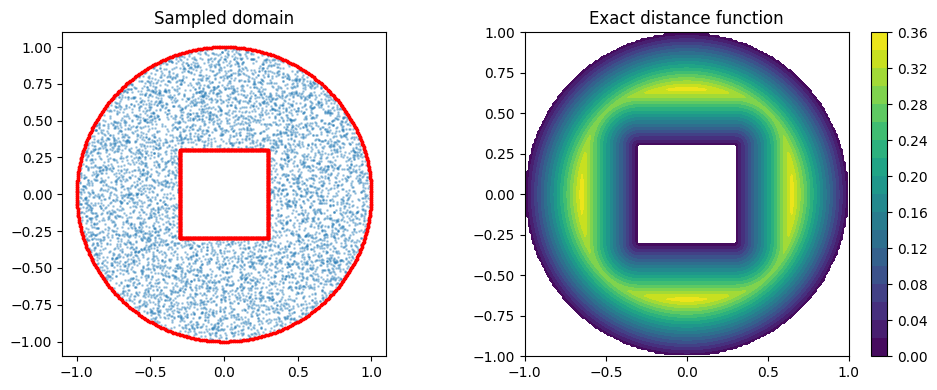

In [4]:
# Visualize the domain
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(interior_pool[::5,0], interior_pool[::5,1], s=1, alpha=0.3)
axes[0].scatter(boundary_pool[:,0], boundary_pool[:,1], s=3, c='red')
axes[0].set_aspect('equal'); axes[0].set_title('Sampled domain')

# Exact solution
xg = jnp.linspace(-1, 1, 200)
X, Y = jnp.meshgrid(xg, xg)
XY_grid = jnp.stack([X.ravel(), Y.ravel()], axis=1)
mask_grid = in_domain_np(np.array(XY_grid))
U_exact = jax.vmap(exact_solution)(XY_grid)
U_exact = np.where(mask_grid, np.array(U_exact), np.nan).reshape(200, 200)
c = axes[1].contourf(X, Y, U_exact, levels=20, cmap='viridis')
plt.colorbar(c, ax=axes[1])
axes[1].set_aspect('equal'); axes[1].set_title('Exact distance function')
plt.tight_layout(); plt.show()

## Model and PDE residual

In [5]:
class EikonalPINN2D(eqx.Module):
    mlp: eqx.nn.MLP

    def __call__(self, xy):
        out = self.mlp(xy)
        return jnp.squeeze(out, axis=-1)

def make_model(key, width=64, depth=4):
    mlp = eqx.nn.MLP(
        in_size=2, out_size=1, width_size=width,
        depth=depth, activation=jnp.tanh, key=key
    )
    return EikonalPINN2D(mlp=mlp)

def pde_residual(model, xy, epsilon=0.0):
    def u_fn(xy):
        return model(xy)
    grad_u = jax.grad(u_fn)(xy)
    grad_norm_sq = jnp.sum(grad_u**2)
    hess = jax.hessian(u_fn)(xy)
    laplacian = hess[0, 0] + hess[1, 1]
    return grad_norm_sq - 1.0 - epsilon * laplacian

In [6]:
# Quick test
k1, key = jrandom.split(key)
test_model = make_model(k1)
print("Output at (0.5, 0.5):", test_model(jnp.array([0.5, 0.5])))
print("Residual:", pde_residual(test_model, jnp.array([0.5, 0.5]), 0.0))

Output at (0.5, 0.5): -0.0459453


Residual: -0.99216646


## Training loop

Soft BC with strong penalty. Sampling from pre-computed pools, so JIT works fine.

In [7]:
def train(model, steps, lr=1e-3, batch_int=2048, batch_bnd=400,
          epsilon=0.0, bc_weight=20.0, seed=0, log_every=500):
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    def loss_fn(model, key):
        k1, k2 = jrandom.split(key)
        idx_i = jrandom.choice(k1, n_int, shape=(batch_int,))
        xi = x_int_pool[idx_i]
        res = jax.vmap(lambda xy: pde_residual(model, xy, epsilon))(xi)
        l_pde = jnp.mean(res**2)
        idx_b = jrandom.choice(k2, n_bnd, shape=(batch_bnd,))
        xb = x_bnd_pool[idx_b]
        ub = jax.vmap(model)(xb)
        l_bc = jnp.mean(ub**2)
        return l_pde + bc_weight * l_bc, (l_pde, l_bc)

    lg = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

    @eqx.filter_jit
    def step_fn(model, opt_state, key):
        (loss, aux), grads = lg(model, key)
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss, aux

    rng = jrandom.PRNGKey(seed)
    history = []
    for i in range(1, steps + 1):
        rng, sk = jrandom.split(rng)
        model, opt_state, loss, (l_pde, l_bc) = step_fn(model, opt_state, sk)
        history.append({'loss': float(loss), 'pde': float(l_pde), 'bc': float(l_bc)})
        if i % log_every == 0 or i == 1:
            print(f"  step {i:5d} | loss={loss:.3e} pde={l_pde:.3e} bc={l_bc:.3e}")
    return model, history

In [8]:
# Sanity check: 100 steps
k1, key = jrandom.split(key)
m_test = make_model(k1)
m_test, _ = train(m_test, steps=100, log_every=50)

  step     1 | loss=1.011e+00 pde=9.980e-01 bc=6.338e-04
  step    50 | loss=1.000e+00 pde=9.999e-01 bc=9.593e-06


  step   100 | loss=1.000e+00 pde=9.999e-01 bc=4.685e-06


## Evaluation helpers

In [9]:
# Pre-compute evaluation grid once (reused by all plot calls)
_eval_n = 200
_eval_xg = jnp.linspace(-1, 1, _eval_n)
_eval_X, _eval_Y = jnp.meshgrid(_eval_xg, _eval_xg)
_eval_XY = jnp.stack([_eval_X.ravel(), _eval_Y.ravel()], axis=1)
_eval_mask = jnp.array(in_domain_np(np.array(_eval_XY)))
_eval_U_true = jax.vmap(exact_solution)(_eval_XY)

def plot_comparison(model, title=""):
    U_pred = jax.vmap(model)(_eval_XY)
    U_true = _eval_U_true
    err = jnp.abs(U_pred - U_true)
    # Mask out points outside domain
    UP = jnp.where(_eval_mask, U_pred, jnp.nan).reshape(_eval_n, _eval_n)
    UT = jnp.where(_eval_mask, U_true, jnp.nan).reshape(_eval_n, _eval_n)
    E = jnp.where(_eval_mask, err, jnp.nan).reshape(_eval_n, _eval_n)
    valid_err = err[_eval_mask]
    me = float(jnp.mean(valid_err))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    c0 = axes[0].contourf(_eval_X, _eval_Y, UP, levels=20, cmap='viridis')
    plt.colorbar(c0, ax=axes[0]); axes[0].set_title('Predicted u')
    c1 = axes[1].contourf(_eval_X, _eval_Y, UT, levels=20, cmap='viridis')
    plt.colorbar(c1, ax=axes[1]); axes[1].set_title('Exact u')
    c2 = axes[2].contourf(_eval_X, _eval_Y, E, levels=20, cmap='hot')
    plt.colorbar(c2, ax=axes[2])
    axes[2].set_title(f'|Error| (mean={me:.4f})')
    for ax in axes: ax.set_aspect('equal')
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()
    return me, float(jnp.max(valid_err))

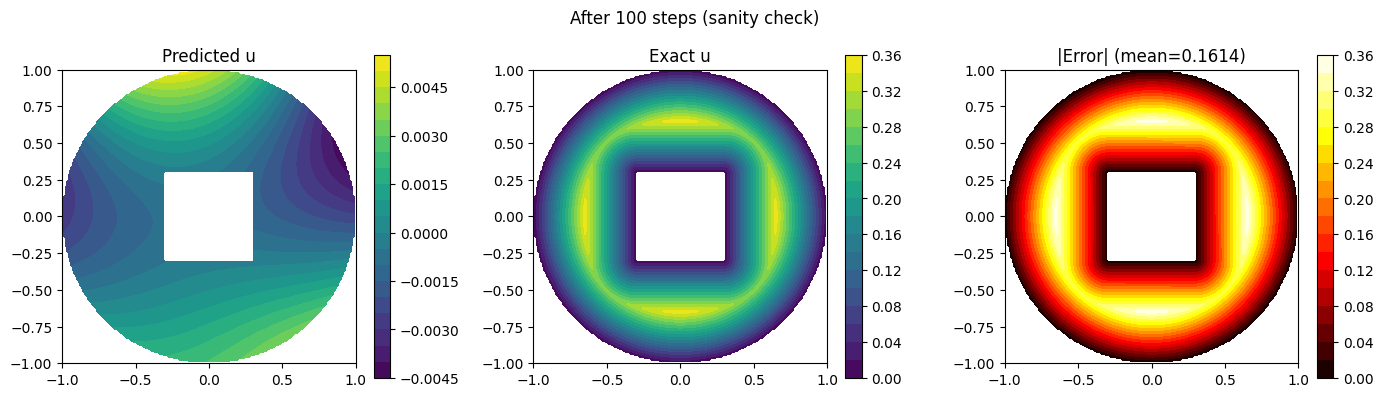

(0.16143454611301422, 0.35038846731185913)

In [10]:
# Sanity check plot (should be bad)
plot_comparison(m_test, "After 100 steps (sanity check)")

## Curriculum learning (epsilon annealing)

Starting with large epsilon to get a smooth initial guess, then gradually reducing to approach the true Eikonal.

In [11]:
eps_schedule = [1.0, 0.3, 0.1, 0.03, 0.01, 0.003, 0.0]
steps_per_stage = 3000

k1, key = jrandom.split(key)
model_c = make_model(k1, width=64, depth=4)
all_hist = []
stage_models = []

for eps in eps_schedule:
    print(f"\n=== Stage eps={eps} ===")
    model_c, hist = train(model_c, steps=steps_per_stage, lr=1e-3,
                          batch_int=2048, batch_bnd=400,
                          epsilon=eps, bc_weight=20.0, log_every=1000)
    all_hist.extend([(eps, h) for h in hist])
    stage_models.append((eps, model_c))


=== Stage eps=1.0 ===


  step     1 | loss=1.017e+00 pde=9.745e-01 bc=2.142e-03


  step  1000 | loss=8.861e-02 pde=5.360e-02 bc=1.750e-03


  step  2000 | loss=2.493e-03 pde=5.618e-04 bc=9.656e-05


  step  3000 | loss=4.452e-03 pde=1.144e-03 bc=1.654e-04

=== Stage eps=0.3 ===


...

  step  3000 | loss=7.232e-03 pde=6.531e-03 bc=3.504e-05

=== Stage eps=0.0 ===


  step     1 | loss=1.704e-02 pde=1.660e-02 bc=2.225e-05


  step  1000 | loss=2.040e-02 pde=1.801e-02 bc=1.193e-04


  step  2000 | loss=1.392e-02 pde=1.164e-02 bc=1.139e-04


  step  3000 | loss=1.723e-02 pde=1.509e-02 bc=1.074e-04


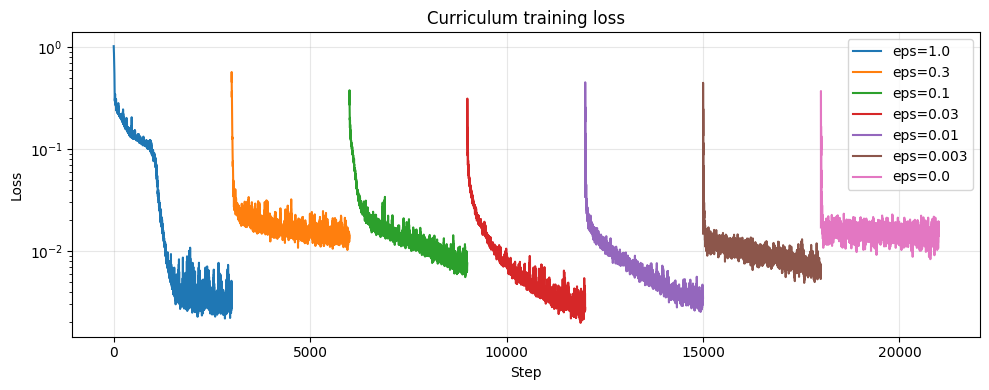

In [12]:
# Loss curve by stage
fig, ax = plt.subplots(figsize=(10, 4))
prev_eps = None; start = 0
for i, (eps, h) in enumerate(all_hist):
    if eps != prev_eps:
        if prev_eps is not None:
            losses = [v['loss'] for _, v in all_hist[start:i]]
            ax.plot(range(start, i), losses, label=f'eps={prev_eps}')
        start = i; prev_eps = eps
losses = [v['loss'] for _, v in all_hist[start:]]
ax.plot(range(start, len(all_hist)), losses, label=f'eps={prev_eps}')
ax.set_yscale('log'); ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Curriculum training loss'); plt.tight_layout(); plt.show()

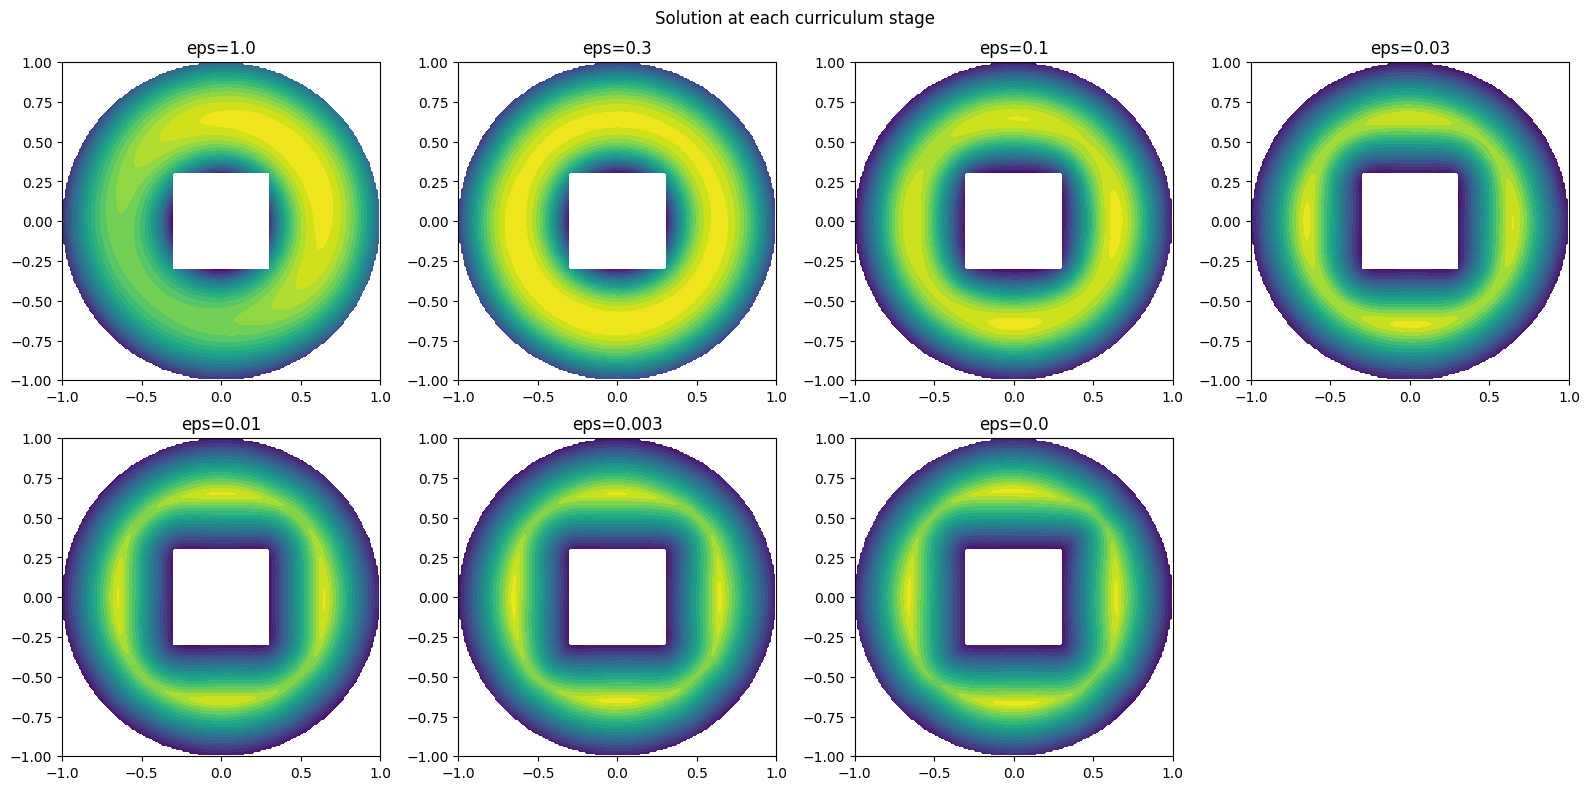

In [13]:
# Solution at each stage
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, (eps, m) in enumerate(stage_models):
    U_pred = jax.vmap(m)(_eval_XY)
    UP = jnp.where(_eval_mask, U_pred, jnp.nan).reshape(_eval_n, _eval_n)
    row, col = idx // 4, idx % 4
    c = axes[row, col].contourf(_eval_X, _eval_Y, UP, levels=20, cmap='viridis')
    axes[row, col].set_title(f'eps={eps}')
    axes[row, col].set_aspect('equal')
axes[1, 3].axis('off')
plt.suptitle('Solution at each curriculum stage')
plt.tight_layout(); plt.show()

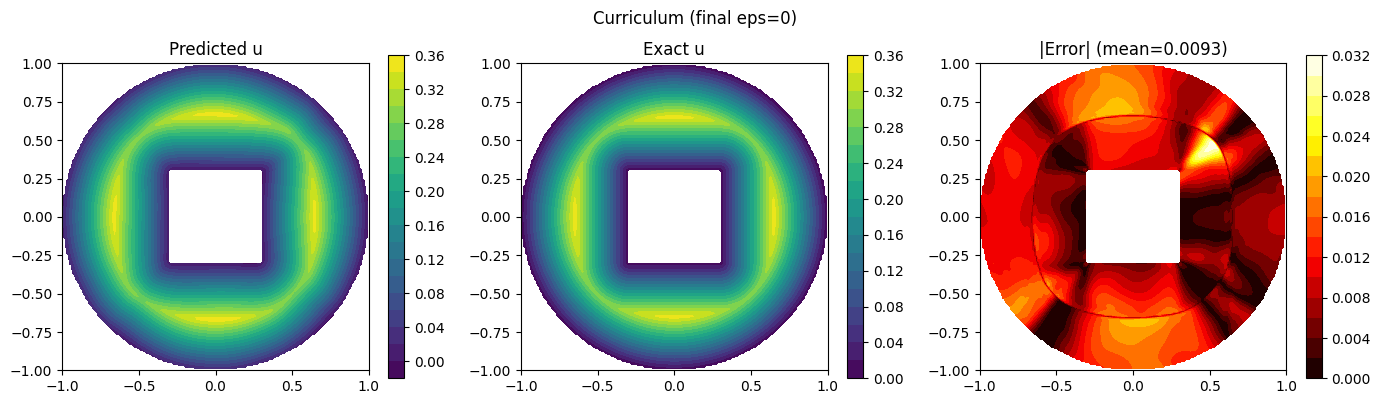

Mean error: 0.0093, Max error: 0.0317


In [14]:
mean_err, max_err = plot_comparison(model_c, "Curriculum (final eps=0)")
print(f"Mean error: {mean_err:.4f}, Max error: {max_err:.4f}")

## Self-adaptive loss weighting

Fine-tuning with per-point trainable weights. Weights do gradient ascent, concentrating on the hardest points (near the square hole corners and the medial axis).

In [15]:
class AdaptiveWeights(eqx.Module):
    w_pde: jnp.ndarray
    w_bc: jnp.ndarray

def finetune_adaptive(model, steps=5000, lr_model=5e-4, lr_w=5e-4,
                      batch_int=2048, batch_bnd=400, seed=0, log_every=500):
    rng = jrandom.PRNGKey(seed)
    weights = AdaptiveWeights(
        w_pde=jnp.ones(batch_int),
        w_bc=jnp.ones(batch_bnd)
    )
    opt_m = optax.adam(lr_model)
    opt_w = optax.adam(lr_w)
    opt_m_state = opt_m.init(eqx.filter(model, eqx.is_array))
    opt_w_state = opt_w.init(weights)
    history = []

    def loss_fn(params, key):
        model, w = params
        k1, k2 = jrandom.split(key)
        idx_i = jrandom.choice(k1, n_int, shape=(batch_int,))
        xi = x_int_pool[idx_i]
        res = jax.vmap(lambda xy: pde_residual(model, xy, 0.0))(xi)
        l_pde = jnp.mean(w.w_pde * res**2)
        idx_b = jrandom.choice(k2, n_bnd, shape=(batch_bnd,))
        xb = x_bnd_pool[idx_b]
        ub = jax.vmap(model)(xb)
        l_bc = jnp.mean(w.w_bc * ub**2)
        return l_pde + 20.0 * l_bc, (l_pde, l_bc)

    lg = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

    @eqx.filter_jit
    def step_fn(params, opt_m_state, opt_w_state, key):
        (loss, aux), grads = lg(params, key)
        g_model, g_w = grads
        model, w = params
        upd_m, opt_m_state = opt_m.update(g_model, opt_m_state, model)
        model = eqx.apply_updates(model, upd_m)
        g_w_neg = jax.tree.map(lambda g: -g, g_w)
        upd_w, opt_w_state = opt_w.update(g_w_neg, opt_w_state, w)
        w = eqx.apply_updates(w, upd_w)
        w = jax.tree.map(lambda x: jnp.maximum(x, 0.01), w)
        return (model, w), opt_m_state, opt_w_state, loss, aux

    params = (model, weights)
    for i in range(1, steps + 1):
        rng, sk = jrandom.split(rng)
        params, opt_m_state, opt_w_state, loss, (l_pde, l_bc) = step_fn(
            params, opt_m_state, opt_w_state, sk)
        history.append({'loss': float(loss), 'pde': float(l_pde), 'bc': float(l_bc)})
        if i % log_every == 0 or i == 1:
            _, w = params
            print(f"  step {i:5d} | loss={loss:.3e} pde={l_pde:.3e} bc={l_bc:.3e}"
                  f" | w_pde={float(w.w_pde.mean()):.2f} w_bc={float(w.w_bc.mean()):.2f}")
    model, weights = params
    return model, weights, history

In [16]:
model_sa, w_sa, hist_sa = finetune_adaptive(model_c, steps=5000, log_every=1000)

  step     1 | loss=1.546e-02 pde=1.393e-02 bc=7.627e-05 | w_pde=1.00 w_bc=1.00


  step  1000 | loss=1.282e-02 pde=1.180e-02 bc=5.085e-05 | w_pde=1.08 w_bc=1.19


  step  2000 | loss=1.349e-02 pde=1.260e-02 bc=4.435e-05 | w_pde=1.15 w_bc=1.40


  step  3000 | loss=1.382e-02 pde=1.315e-02 bc=3.353e-05 | w_pde=1.22 w_bc=1.63


  step  4000 | loss=1.035e-02 pde=9.517e-03 bc=4.154e-05 | w_pde=1.29 w_bc=1.88


  step  5000 | loss=1.214e-02 pde=1.116e-02 bc=4.892e-05 | w_pde=1.35 w_bc=2.11


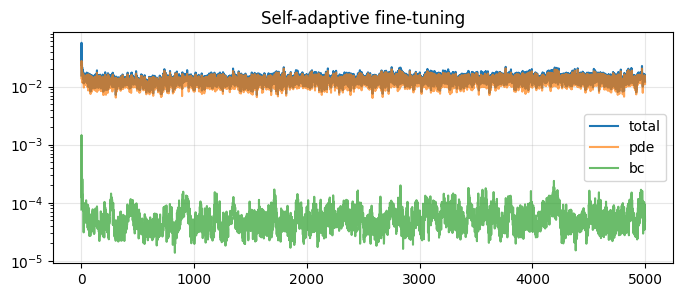

In [17]:
# Loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot([h['loss'] for h in hist_sa], label='total')
ax.plot([h['pde'] for h in hist_sa], label='pde', alpha=0.7)
ax.plot([h['bc'] for h in hist_sa], label='bc', alpha=0.7)
ax.set_yscale('log'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Self-adaptive fine-tuning'); plt.show()

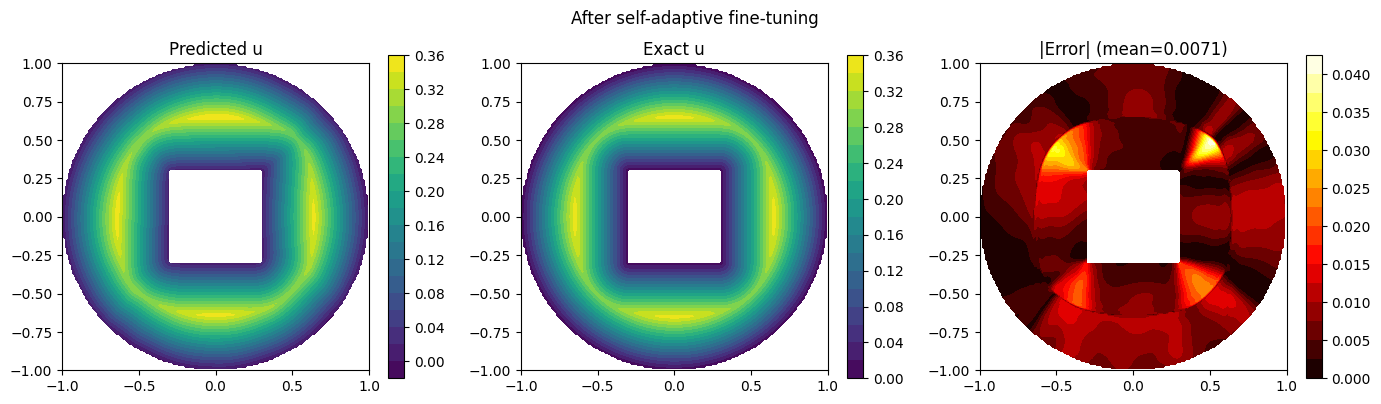

Mean error: 0.0071, Max error: 0.0424


In [18]:
mean_err, max_err = plot_comparison(model_sa, "After self-adaptive fine-tuning")
print(f"Mean error: {mean_err:.4f}, Max error: {max_err:.4f}")

## Cross-sections

Checking the solution along y=0 (through the middle of the square hole) and along the diagonal.

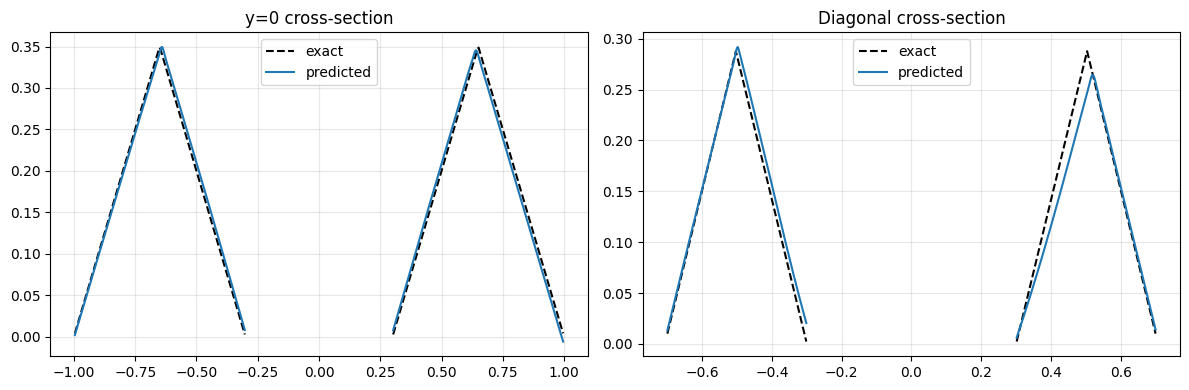

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# y=0 cross-section
xline = jnp.linspace(-1.0, 1.0, 500)
xy_y0 = jnp.stack([xline, jnp.zeros_like(xline)], axis=1)
mask_y0 = jnp.array(in_domain_np(np.array(xy_y0)))
u_pred = jnp.where(mask_y0, jax.vmap(model_sa)(xy_y0), jnp.nan)
u_true = jnp.where(mask_y0, jax.vmap(exact_solution)(xy_y0), jnp.nan)
axes[0].plot(xline, u_true, 'k--', label='exact')
axes[0].plot(xline, u_pred, label='predicted')
axes[0].set_title('y=0 cross-section'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Diagonal cross-section
t = jnp.linspace(-0.7, 0.7, 500)
xy_diag = jnp.stack([t, t], axis=1)
mask_d = jnp.array(in_domain_np(np.array(xy_diag)))
u_pred_d = jnp.where(mask_d, jax.vmap(model_sa)(xy_diag), jnp.nan)
u_true_d = jnp.where(mask_d, jax.vmap(exact_solution)(xy_diag), jnp.nan)
axes[1].plot(t, u_true_d, 'k--', label='exact')
axes[1].plot(t, u_pred_d, label='predicted')
axes[1].set_title('Diagonal cross-section'); axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

The solution should capture both the distance to the outer circle and the distance to the inner square hole, with a medial axis where these two distances are equal.